In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [8]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


exploratory data analysis to understand churn patterns and key risk drivers.

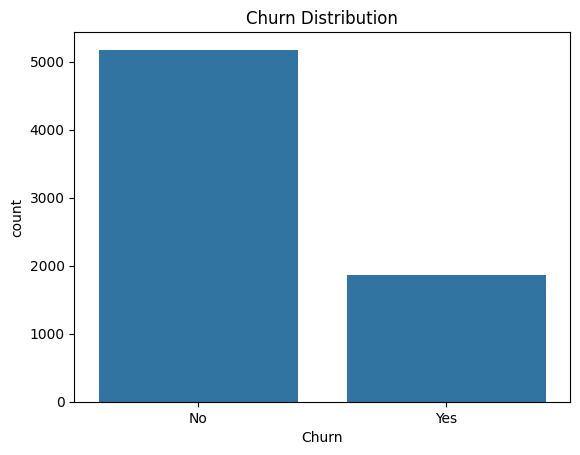

In [13]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()


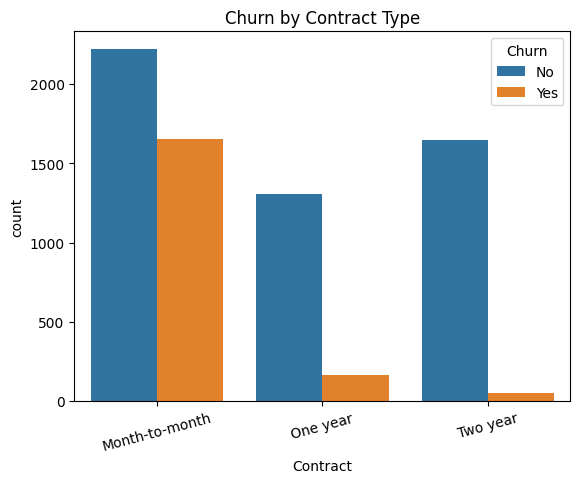

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

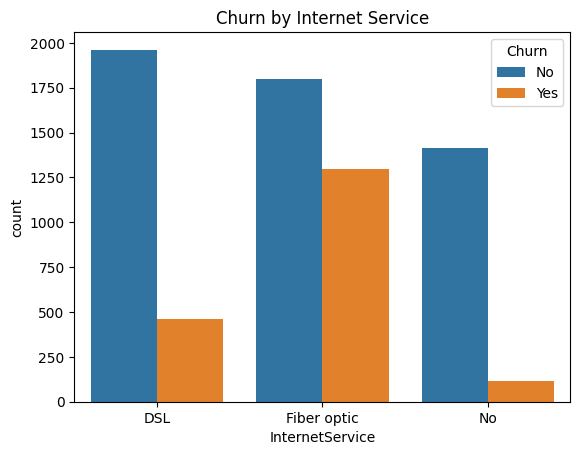

In [15]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service')
plt.show()

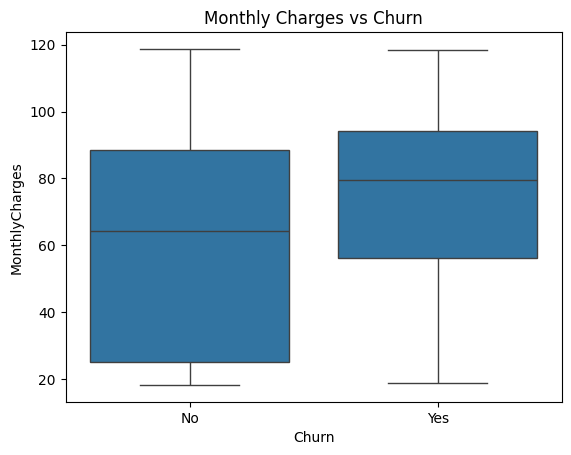

In [16]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

In [17]:
df.drop('customerID', axis=1, inplace=True)

In [18]:
from sklearn.model_selection import train_test_split
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [19]:
X


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [20]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [21]:
y = df['Churn'].map({'Yes':1, 'No':0})

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((5634, 19), (1409, 19))

In [23]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)


In [24]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pipelines = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),
    
    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Probabilities (for ROC-AUC)
    y_train_proba = pipeline.predict_proba(X_train)[:, 1]
    y_test_proba = pipeline.predict_proba(X_test)[:, 1]

    print(name)
    print("Model performance for Training set")
    print("- Accuracy: {:.4f}".format(accuracy_score(y_train, y_train_pred)))
    print("- F1 Score: {:.4f}".format(f1_score(y_train, y_train_pred)))
    print("- Precision: {:.4f}".format(precision_score(y_train, y_train_pred)))
    print("- Recall: {:.4f}".format(recall_score(y_train, y_train_pred)))
    print("- ROC-AUC: {:.4f}".format(roc_auc_score(y_train, y_train_proba)))

    print("----------------------------------")

    print("Model performance for Test set")
    print("- Accuracy: {:.4f}".format(accuracy_score(y_test, y_test_pred)))
    print("- F1 Score: {:.4f}".format(f1_score(y_test, y_test_pred)))
    print("- Precision: {:.4f}".format(precision_score(y_test, y_test_pred)))
    print("- Recall: {:.4f}".format(recall_score(y_test, y_test_pred)))
    print("- ROC-AUC: {:.4f}".format(roc_auc_score(y_test, y_test_proba)))

    print("=" * 45, "\n")


Logistic Regression
Model performance for Training set
- Accuracy: 0.8035
- F1 Score: 0.5932
- Precision: 0.6588
- Recall: 0.5394
- ROC-AUC: 0.8444
----------------------------------
Model performance for Test set
- Accuracy: 0.8211
- F1 Score: 0.6390
- Precision: 0.6862
- Recall: 0.5979
- ROC-AUC: 0.8621

Decision Tree
Model performance for Training set
- Accuracy: 0.9986
- F1 Score: 0.9973
- Precision: 0.9987
- Recall: 0.9960
- ROC-AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.7083
- F1 Score: 0.4513
- Precision: 0.4495
- Recall: 0.4531
- ROC-AUC: 0.6283

Random Forest
Model performance for Training set
- Accuracy: 0.9986
- F1 Score: 0.9973
- Precision: 0.9967
- Recall: 0.9980
- ROC-AUC: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.7942
- F1 Score: 0.5426
- Precision: 0.6590
- Recall: 0.4611
- ROC-AUC: 0.8391

Gradient Boosting
Model performance for Training set
- Accuracy: 0.8243
- F1 Score: 0.62

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])


In [28]:
param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [8, 12, 16],
    "model__min_samples_split": [5, 10],
    "model__min_samples_leaf": [2, 4]
}


In [29]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'Onli...
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [8, 12, 16],
                         'model__min_samples_leaf': [2, 4],
                         'model__min_samples_split': [5, 10],
                         'model__n_estimators': [200, 300]},
             scoring='roc_auc', verbose=2)

In [30]:
best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [41]:
from sklearn.metrics import roc_auc_score, classification_report

y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Probabilities (for ROC-AUC)
y_train_proba = best_rf.predict_proba(X_train)[:, 1]
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(accuracy_score(y_train, y_train_pred)))
print("- F1 Score: {:.4f}".format(f1_score(y_train, y_train_pred)))
print("- Precision: {:.4f}".format(precision_score(y_train, y_train_pred)))
print("- Recall: {:.4f}".format(recall_score(y_train, y_train_pred)))
print("- ROC-AUC: {:.4f}".format(roc_auc_score(y_train, y_train_proba)))

print("----------------------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(accuracy_score(y_test, y_test_pred)))
print("- F1 Score: {:.4f}".format(f1_score(y_test, y_test_pred)))
print("- Precision: {:.4f}".format(precision_score(y_test, y_test_pred)))
print("- Recall: {:.4f}".format(recall_score(y_test, y_test_pred)))
print("- ROC-AUC: {:.4f}".format(roc_auc_score(y_test, y_test_proba)))
# y_test_pred = best_rf.predict(X_test)
# y_test_proba = best_rf.predict_proba(X_test)[:, 1]

# print("Tuned Random Forest ROC-AUC:", roc_auc_score(y_test, y_test_proba))


Random Forest
Model performance for Training set
- Accuracy: 0.8204
- F1 Score: 0.6065
- Precision: 0.7249
- Recall: 0.5214
- ROC-AUC: 0.8880
----------------------------------
Model performance for Test set
- Accuracy: 0.8070
- F1 Score: 0.5750
- Precision: 0.6891
- Recall: 0.4933
- ROC-AUC: 0.8652
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__subsample=0.8; total time=   1.3s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   1.4s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   1.4s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__subsample=0.8; total time=   2.4s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=200, model__subsample=1.0; total time=   2.7s
[CV] END model__learning_rate=0.05, model__max_depth=5, model__n_estimators=100, model__s

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])


In [37]:
param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0]
}


In [38]:
from sklearn.model_selection import GridSearchCV

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

gb_grid.fit(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'Onli...otection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=2)

In [39]:
best_gb = gb_grid.best_estimator_

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)


Best Gradient Boosting Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}


In [40]:
from sklearn.metrics import roc_auc_score, classification_report

y_train_pred = best_gb.predict(X_train)
y_test_pred = best_gb.predict(X_test)

# Probabilities (for ROC-AUC)
y_train_proba = best_gb.predict_proba(X_train)[:, 1]
y_test_proba = best_gb.predict_proba(X_test)[:, 1]

print("Gradient boosting")
print("Model performance for Training set")
print("- Accuracy: {:.4f}".format(accuracy_score(y_train, y_train_pred)))
print("- F1 Score: {:.4f}".format(f1_score(y_train, y_train_pred)))
print("- Precision: {:.4f}".format(precision_score(y_train, y_train_pred)))
print("- Recall: {:.4f}".format(recall_score(y_train, y_train_pred)))
print("- ROC-AUC: {:.4f}".format(roc_auc_score(y_train, y_train_proba)))

print("----------------------------------")

print("Model performance for Test set")
print("- Accuracy: {:.4f}".format(accuracy_score(y_test, y_test_pred)))
print("- F1 Score: {:.4f}".format(f1_score(y_test, y_test_pred)))
print("- Precision: {:.4f}".format(precision_score(y_test, y_test_pred)))
print("- Recall: {:.4f}".format(recall_score(y_test, y_test_pred)))
print("- ROC-AUC: {:.4f}".format(roc_auc_score(y_test, y_test_proba)))



Gradient boosting
Model performance for Training set
- Accuracy: 0.8119
- F1 Score: 0.5936
- Precision: 0.6960
- Recall: 0.5174
- ROC-AUC: 0.8640
----------------------------------
Model performance for Test set
- Accuracy: 0.8162
- F1 Score: 0.6058
- Precision: 0.7007
- Recall: 0.5335
- ROC-AUC: 0.8657


In [43]:
model = best_gb.named_steps["model"]
preprocessor = best_gb.named_steps["preprocessor"]

In [44]:
preprocessor.transformers_

[('num',
  StandardScaler(),
  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
 ('cat',
  OneHotEncoder(drop='first', handle_unknown='ignore'),
  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
         'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
         'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
         'PaperlessBilling', 'PaymentMethod'],
        dtype='object'))]

In [45]:
num_features = preprocessor.transformers_[0][2]
cat_features = preprocessor.transformers_[1][2]

In [46]:
ohe = preprocessor.transformers_[1][1]

In [47]:
ohe_feature_names = ohe.get_feature_names_out(cat_features)

In [48]:
feature_names = list(num_features) + list(ohe_feature_names)

In [49]:
importances = model.feature_importances_

In [50]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

In [51]:
feature_importance_df.head(15)

,Feature,Importance
1,tenure,0.334086
10,InternetService_Fiber optic,0.200979
28,PaymentMethod_Electronic check,0.098039
25,Contract_Two year,0.079197
24,Contract_One year,0.057567
3,TotalCharges,0.048418
2,MonthlyCharges,0.047923
13,OnlineSecurity_Yes,0.022009
26,PaperlessBilling_Yes,0.020363
23,StreamingMovies_Yes,0.014580
